# Decision Tree Tutorial: Effect of Tree Depth on Overfitting and Underfitting
Name: Arman Ali Zaib    
Student ID: 24168194

This notebook demonstrates how the depth of a decision tree affects model performance. We explore how increasing depth can lead to overfitting and how to find an optimal balance.

Dataset used: Breast Cancer Wisconsin Dataset

This notebook can be run directly without downloading any external dataset.

## 1. Importing Libraries

In this section, we import the required libraries for data handling, model training, and visualization.

In [1]:
# Importing required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn import tree

## 2. Loading Dataset

We use the Breast Cancer Wisconsin dataset, which is a binary classification problem where the goal is to classify tumors as benign or malignant.

In [2]:
# Loading the Breast Cancer dataset from sklearn
# X contains feature values, y contains target labels

data = load_breast_cancer()

X = data.data
y = data.target

feature_names = data.feature_names
target_names = data.target_names

print("Dataset shape:", X.shape)
print("Target classes:", target_names)

Dataset shape: (569, 30)
Target classes: ['malignant' 'benign']


## 3. Splitting the Data

The dataset is split into training and testing sets. The model learns from the training data and is evaluated on unseen test data.

In [3]:
# Splitting the dataset into training and testing sets
# 80% for training and 20% for testing

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


## 4. Experiment: Effect of Tree Depth

We train multiple decision tree models with different depths to observe how model complexity affects performance.

In [4]:
# Looping through different tree depths to evaluate performance
# Storing training and testing accuracy for comparison

depths = [1, 3, 5, 10]

train_accuracy = []
test_accuracy = []

for depth in depths:

    model = DecisionTreeClassifier(max_depth=depth, random_state=42)

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    train_accuracy.append(train_acc)
    test_accuracy.append(test_acc)

    print(f"Depth {depth}")
    print("Training Accuracy:", train_acc)
    print("Test Accuracy:", test_acc)
    print("-------------------------")

Depth 1
Training Accuracy: 0.9208791208791208
Test Accuracy: 0.8947368421052632
-------------------------
Depth 3
Training Accuracy: 0.978021978021978
Test Accuracy: 0.9473684210526315
-------------------------
Depth 5
Training Accuracy: 0.9956043956043956
Test Accuracy: 0.9473684210526315
-------------------------
Depth 10
Training Accuracy: 1.0
Test Accuracy: 0.9473684210526315
-------------------------


## 5. Results: Accuracy vs Tree Depth

This plot shows how training and test accuracy change as the depth of the tree increases.

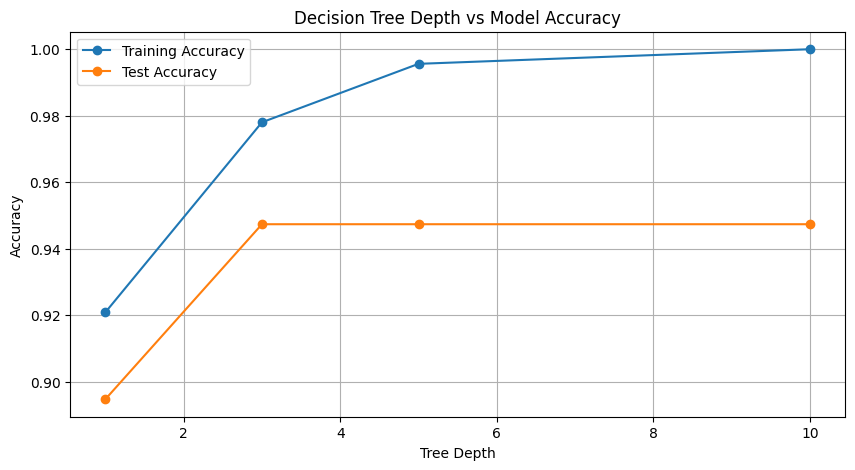

In [5]:
# Plotting the training and testing accuracy for different tree depths
# This will visualize how model performance changes with complexity

plt.figure(figsize=(10,5))

plt.plot(depths, train_accuracy, marker='o', label="Training Accuracy")
plt.plot(depths, test_accuracy, marker='o', label="Test Accuracy")

plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Depth vs Model Accuracy")

plt.legend()
plt.grid()

plt.show()

### Interpretation

From the graph, we observe that:

- Training accuracy increases as tree depth increases
- Test accuracy improves initially but then stabilizes

This shows that deeper trees may overfit the training data without improving generalization.

## 6. Final Model Selection

We select a tree depth that provides a good balance between performance and generalization.

In [6]:
# Trainning the final decision tree model using selected depth
# This depth is chosen based on best balance between training and test performance

final_model = DecisionTreeClassifier(max_depth=3, random_state=42)

final_model.fit(X_train, y_train)

# Make predictions using the trained model on test data
# These predictions will be used to evaluate model performance

y_pred = final_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Final Model Accuracy:", accuracy)

Final Model Accuracy: 0.9473684210526315


## 7. Model Evaluation

The confusion matrix shows how well the model performs in classification.

In [7]:
# Generate confusion matrix to evaluate classification performance
# It shows correct and incorrect predictions for each class
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[39  4]
 [ 2 69]]


## 8. Decision Tree Visualization

The tree structure helps us understand how the model makes decisions step by step.

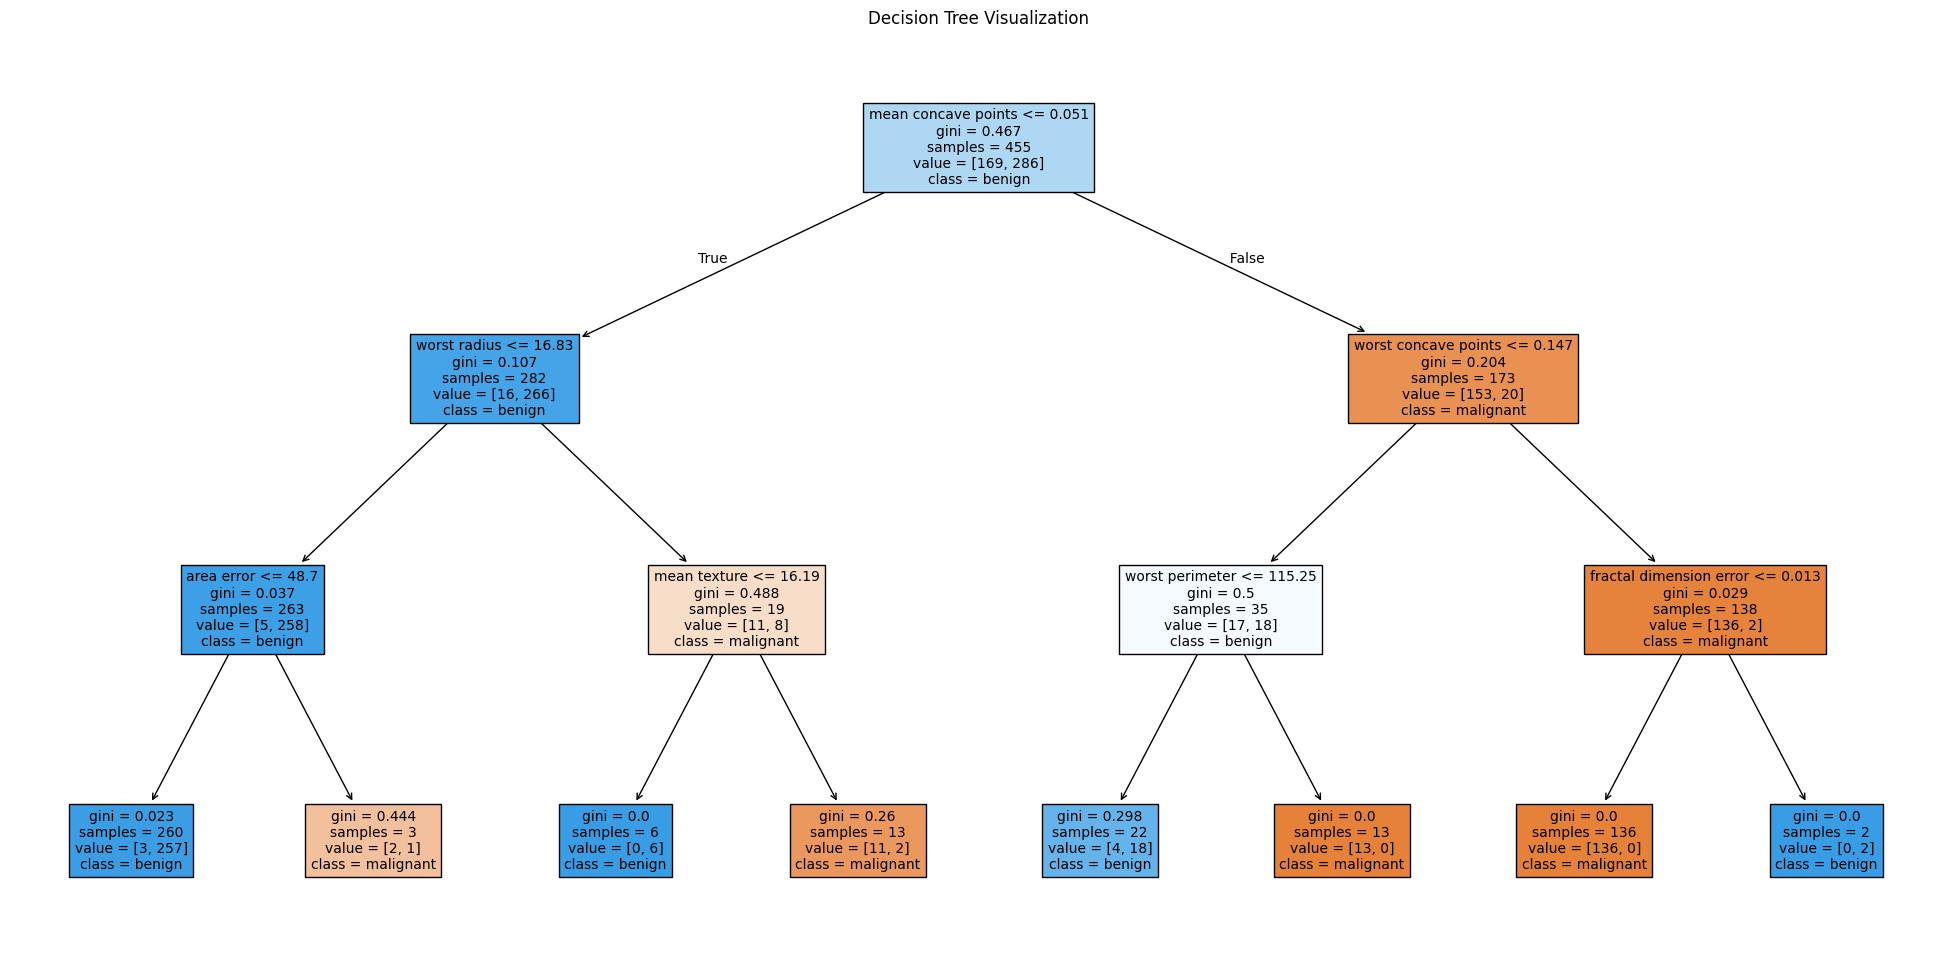

In [8]:
# Visualize the structure of the decision tree
# This helps us understand how the model makes decisions step by step

plt.figure(figsize=(25,12))

tree.plot_tree(
    final_model, 
    feature_names=feature_names,   # Names of input features
    class_names=target_names,      # Output classes (benign/malignant)
    filled=True
)

plt.title("Decision Tree Visualization")

plt.show()

### Understanding the Tree

Each node in the tree represents a decision based on a feature.

- The model splits the data step by step
- Each level increases model complexity
- Deeper trees create more detailed rules

This visualization helps explain why deeper trees can lead to overfitting.